# Analytic vs Numerical Kernel

`spotgp` provides two independent kernel implementations:

| Class | Method | Speed |
|---|---|---|
| `AnalyticKernel` | Closed-form equations derived from the spot model physics | Fast (JAX-compiled) |
| `NumericalKernel` | Monte Carlo: simulate many lightcurves, average the autocovariance | Slow (brute force) |

The numerical kernel serves as a ground-truth benchmark to validate the analytic derivation. This tutorial compares them for consistency and speed.

In [26]:
import sys
sys.path.append("../..")

import time
import numpy as np
import matplotlib.pyplot as plt

from spotgp import (
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    AnalyticKernel,
    NumericalKernel,
)

plt.rcParams.update({                                                                                  
    "font.size":        16,   # base font size                                                         
    "axes.titlesize":   20,   # axes title                                                             
    "axes.labelsize":   18,   # x/y axis labels                                                        
    "xtick.labelsize":  14,   # x tick labels                                                          
    "ytick.labelsize":  14,   # y tick labels                                                          
    "legend.fontsize":  14,                                                                            
    "figure.titlesize": 22,   # suptitle
    "axes.formatter.useoffset": False,  # disable scientific notation offset                                                   
})   

np.random.seed(42)

---
## 1. Define the spot model

We use the same physical parameters for both kernels. The numerical kernel additionally requires `nspot` and `alpha_max` for the forward simulations.

In [7]:
# Shared physical parameters
peq = 5.0        # rotation period [days]
kappa = 0.2      # differential rotation
inc = np.pi / 2  # inclination [rad]
lspot = 10.0     # spot plateau [days]
tau_spot = 5.0   # rise/decay timescale [days]
nspot = 20       # number of spots (for numerical sims)
alpha_max = 0.1  # spot angular radius [rad]
fspot = 0.0      # spot contrast

# Build the hparam dict (accepted by both kernel constructors)
hparam = dict(
    peq=peq, kappa=kappa, inc=inc,
    lspot=lspot, tau_spot=tau_spot,
    nspot=nspot, alpha_max=alpha_max, fspot=fspot,
)

print("Parameters:")
for k, v in hparam.items():
    print(f"  {k:>12s} = {v}")

Parameters:
           peq = 5.0
         kappa = 0.2
           inc = 1.5707963267948966
         lspot = 10.0
      tau_spot = 5.0
         nspot = 20
     alpha_max = 0.1
         fspot = 0.0


---
## 2. Compute both kernels

### Analytic kernel

The analytic kernel evaluates closed-form equations — no simulations needed.

In [18]:
t0 = time.time()
ak = AnalyticKernel(hparam)
t_init_ak = time.time() - t0

lag = np.linspace(0, 3 * peq, 300)

t0 = time.time()
K_analytic = np.array(ak.kernel(lag))
t_eval_ak = time.time() - t0

print(f"AnalyticKernel init:  {t_init_ak:.3f} s")
print(f"AnalyticKernel eval:  {t_eval_ak:.3f} s  ({len(lag)} points)")

AnalyticKernel init:  0.000 s
AnalyticKernel eval:  0.089 s  (300 points)


### Numerical kernel

The numerical kernel simulates `nsim` lightcurves, computes the covariance matrix, and averages along diagonals to get the autocovariance as a function of lag.

```{note}

For the numerical kernel you need to sample a lot of lightcurves with a long baseline to get an accurate estimate, so we set `nsim=2000` and `tsim=100 * peq`. 
```

In [21]:
nsim = 2000
tsim = 100 * peq
tsamp = 0.05

t0 = time.time()
nk = NumericalKernel(hparam, tsim=tsim, tsamp=tsamp, nsim=nsim, verbose=False)
t_init_nk = time.time() - t0

tarr_nk, acf_nk = nk.get_acf()
# Scale numerical ACF to match analytic kernel units:
# numerical autocov is already in flux^2 units; the analytic kernel
# includes sigma_k^2, so they should match directly.
K_numerical = nk.autocov

print(f"NumericalKernel init: {t_init_nk:.3f} s  ({int(nsim)} sims, {len(tarr_nk)} time steps)")

NumericalKernel init: 5.579 s  (2000 sims, 10000 time steps)


---
## 3. Compare: autocorrelation functions

Both kernels should produce the same normalized autocorrelation function. The analytic kernel uses the exact equations while the numerical kernel estimates it from Monte Carlo simulations.

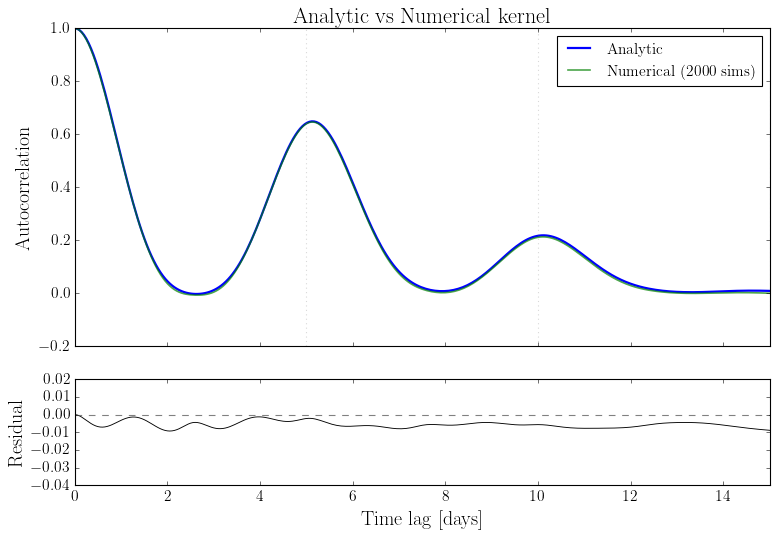

ACF RMSE: 0.0187


In [29]:
# Normalize both to ACF (divide by value at lag=0)
acf_analytic = K_analytic / K_analytic[0]
acf_numerical = acf_nk  # already normalized

fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={"height_ratios": [3, 1]}, sharex=True)

# ACF comparison
axes[0].plot(lag, acf_analytic, "C0", lw=2, label="Analytic")
axes[0].plot(tarr_nk, acf_numerical, "C1", lw=1.5, alpha=0.7,
             label=f"Numerical ({int(nsim)} sims)")
for i in range(1, 4):
    axes[0].axvline(i * peq, color="gray", ls=":", alpha=0.3)
axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("Analytic vs Numerical kernel")
axes[0].legend()
axes[0].set_xlim(0, max(lag))

# Residuals
acf_analytic_interp = np.interp(tarr_nk, lag, acf_analytic)
residual = acf_numerical - acf_analytic_interp
axes[1].plot(tarr_nk, residual, "k", lw=0.8)
axes[1].axhline(0, color="gray", ls="--")
axes[1].set_xlabel("Time lag [days]")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

rmse = np.sqrt(np.mean(residual ** 2))
print(f"ACF RMSE: {rmse:.4f}")

---
## 4. Compare: power spectral density

In [ ]:
# Analytic PSD
omega = np.linspace(0.01, 4 * np.pi / peq, 300)
freq_ak, power_ak = ak.compute_psd(omega)

# Numerical PSD (from simulated lightcurves)
freq_nk, power_nk = nk.compute_psd(nsims=min(200, int(nsim)))

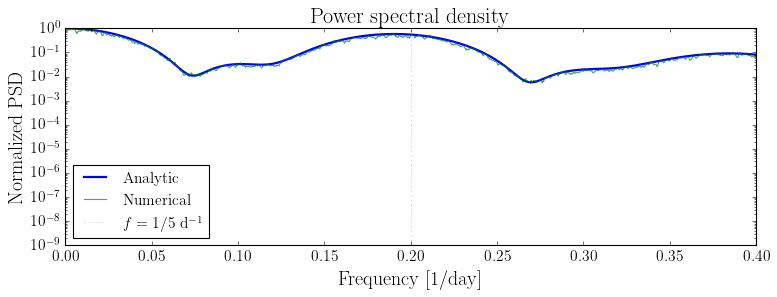

In [28]:
fig, ax = plt.subplots(figsize=(10, 4), sharex=True)
ax.semilogy(freq_ak, np.array(power_ak) / np.max(np.array(power_ak)),
            "C0", lw=2, label="Analytic")
ax.semilogy(freq_nk, power_nk / np.max(power_nk),
            "C1", lw=1, alpha=0.7, label="Numerical")

# Mark rotation frequency and harmonics
f_rot = 1.0 / peq
for n in range(1, 4):
    ax.axvline(n * f_rot, color="gray", ls=":", alpha=0.4,
               label=f"$f = {n}/{peq:.0f}$ d$^{{-1}}$" if n == 1 else None)

ax.set_xlim(0, max(freq_ak))
ax.set_xlabel("Frequency [1/day]")
ax.set_ylabel("Normalized PSD")
ax.set_title("Power spectral density")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

---
## 5. Speed comparison

The analytic kernel is orders of magnitude faster because it evaluates closed-form equations rather than running Monte Carlo simulations.

In [30]:
# Benchmark analytic kernel: repeated evaluation
n_calls = 100
lag_bench = np.linspace(0, 3 * peq, 500)

# Warm up JAX
_ = ak.kernel(lag_bench)

t0 = time.time()
for _ in range(n_calls):
    _ = ak.kernel(lag_bench)
t_analytic = (time.time() - t0) / n_calls

# Numerical kernel: time for different nsim
nsim_values = [100, 500, 1000]
t_numerical = []
for ns in nsim_values:
    t0 = time.time()
    _ = NumericalKernel(hparam, tsim=tsim, tsamp=tsamp, nsim=ns, verbose=False)
    t_numerical.append(time.time() - t0)

print(f"{'Method':<30s}  {'Time':>10s}  {'Speedup':>10s}")
print("-" * 55)
print(f"{'Analytic (500 lags)':<30s}  {t_analytic*1000:>8.1f} ms  {'—':>10s}")
for ns, t in zip(nsim_values, t_numerical):
    speedup = t / t_analytic
    print(f"{'Numerical (nsim=' + str(ns) + ')':<30s}  {t:>8.2f} s   {speedup:>8.0f}x")

Method                                Time     Speedup
-------------------------------------------------------
Analytic (500 lags)                 88.0 ms           —
Numerical (nsim=100)                0.75 s          9x
Numerical (nsim=500)                1.72 s         19x
Numerical (nsim=1000)               2.97 s         34x


---
## 6. Convergence with number of simulations

The numerical kernel approaches the analytic result as `nsim` increases. How many simulations are needed for a given accuracy?

In [ ]:
nsim_grid = [50, 100, 200, 500, 1000, 2000]
rmse_list = []

for ns in nsim_grid:
    nk_test = NumericalKernel(hparam, tsim=tsim, tsamp=tsamp, nsim=ns, verbose=False)
    acf_test = nk_test.autocov / nk_test.autocov[0]
    acf_ref = np.interp(nk_test.tarr, lag, acf_analytic)
    rmse_list.append(np.sqrt(np.mean((acf_test - acf_ref) ** 2)))

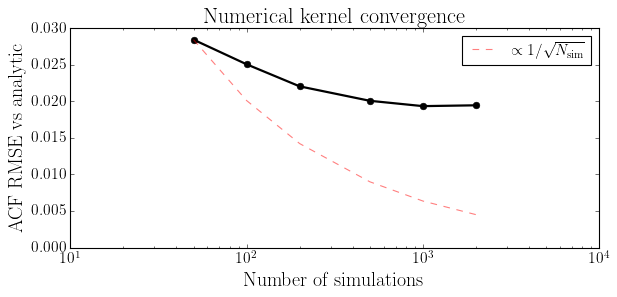

In [32]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(nsim_grid, rmse_list, "ko-", lw=2)
ax.set_xlabel("Number of simulations")
ax.set_ylabel("ACF RMSE vs analytic")
ax.set_title("Numerical kernel convergence")

# Expected scaling: RMSE ~ 1/sqrt(nsim)
ns_ref = np.array(nsim_grid, dtype=float)
scale = rmse_list[0] * np.sqrt(nsim_grid[0])
ax.semilogx(ns_ref, scale / np.sqrt(ns_ref), "r--", alpha=0.5,
          label=r"$\propto 1/\sqrt{N_{\rm sim}}$")
ax.legend()
plt.tight_layout()
plt.show()

What about for `tsim`?

In [33]:
tsim_grid = [50, 100, 200, 500, 1000, 2000]
rmse_list = []

for tsim in tsim_grid:
    nk_test = NumericalKernel(hparam, tsim=tsim, tsamp=tsamp, nsim=1000, verbose=False)
    acf_test = nk_test.autocov / nk_test.autocov[0]
    acf_ref = np.interp(nk_test.tarr, lag, acf_analytic)
    rmse_list.append(np.sqrt(np.mean((acf_test - acf_ref) ** 2)))

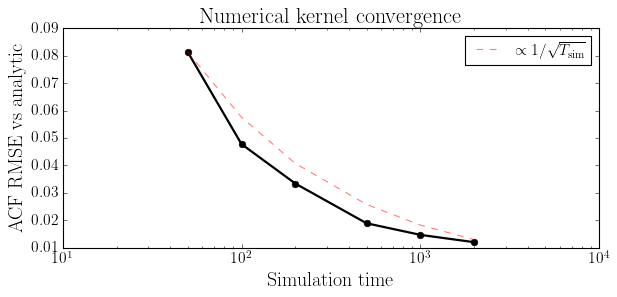

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(tsim_grid, rmse_list, "ko-", lw=2)
ax.set_xlabel("Simulation time")
ax.set_ylabel("ACF RMSE vs analytic")
ax.set_title("Numerical kernel convergence")

# Expected scaling: RMSE ~ 1/sqrt(tsim)
ts_ref = np.array(tsim_grid, dtype=float)
scale = rmse_list[0] * np.sqrt(tsim_grid[0])
ax.semilogx(ts_ref, scale / np.sqrt(ts_ref), "r--", alpha=0.5,
          label=r"$\propto 1/\sqrt{T_{\rm sim}}$")
ax.legend()
plt.tight_layout()
plt.show()

```{note}

To achieve better accuracy with the numerical kernel, increasing `tsim` matters more than increasing `nsim`.
```

---
## 7. Effect of differential rotation

Compare the two kernels across different values of the differential rotation parameter $\kappa$ to verify consistency beyond the default case.

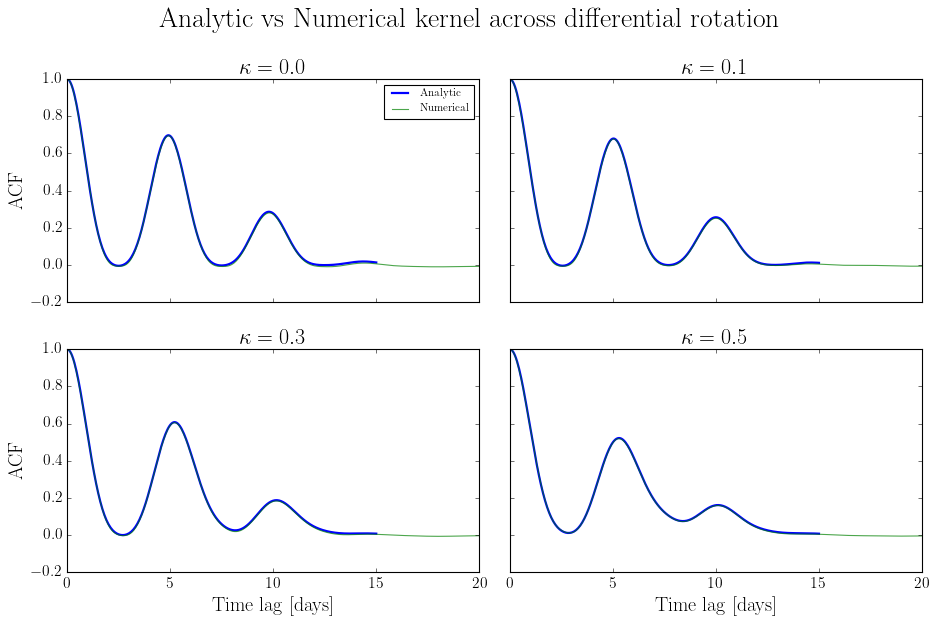

In [37]:
kappa_values = [0.0, 0.1, 0.3, 0.5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, kap in zip(axes.flat, kappa_values):
    hp = dict(hparam, kappa=kap)

    # Analytic
    ak_k = AnalyticKernel(hp)
    K_ak = np.array(ak_k.kernel(lag))
    acf_ak = K_ak / K_ak[0]

    # Numerical
    nk_k = NumericalKernel(hp, tsim=1000, tsamp=tsamp, nsim=1000, verbose=False)
    acf_nk_k = nk_k.autocov / nk_k.autocov[0]

    ax.plot(lag, acf_ak, "C0", lw=2, label="Analytic")
    ax.plot(nk_k.tarr, acf_nk_k, "C1", lw=1, alpha=0.7, label="Numerical")
    ax.set_title(rf"$\kappa = {kap}$")
    ax.set_xlim(0, 4*peq)
    if ax in axes[:, 0]:
        ax.set_ylabel("ACF")
    if ax in axes[1, :]:
        ax.set_xlabel("Time lag [days]")

axes[0, 0].legend(fontsize=10)
plt.suptitle("Analytic vs Numerical kernel across differential rotation", fontsize=25)
plt.tight_layout()
plt.show()

---
## Summary

| | Analytic | Numerical |
|---|---|---|
| **Method** | Closed-form $R_\Gamma \times$ Fourier visibility | Monte Carlo autocovariance |
| **Speed** | Milliseconds | Seconds to minutes |
| **Accuracy** | Exact (small-spot limit) | Converges as $1/\sqrt{T_{\rm sim}}$ |
| **Differentiable** | Yes (JAX autodiff) | No |
| **Use case** | Inference (GP fitting, MCMC) | Validation and benchmarking |

The analytic kernel is the right choice for inference. The numerical kernel is useful for:
- Validating the analytic derivation against brute-force simulations
- Checking regimes where the small-spot approximation may break down
- Building intuition about how parameters affect the lightcurve statistics